In [ ]:
!kaggle datasets download -d rajyellow46/wine-quality

Dataset URL: https://www.kaggle.com/datasets/rajyellow46/wine-quality
License(s): other
100% 98.0k/98.0k [00:00<00:00, 89.8MB/s]



In [ ]:
import zipfile
zip = zipfile.ZipFile("/content/wine-quality.zip",'r')
zip.extractall("/content")
zip.close()

In [ ]:
import pandas as pd
df=pd.read_csv('/content/winequalityN.csv')
df

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [ ]:
df.isnull().sum()

,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [ ]:
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'float64' or df[col].dtype == 'int64':
            df[col].fillna(df[col].mean(), inplace=True)
        else:
            pass

print("Missing values after handling:")
display(df.isnull().sum())

Missing values after handling:


/tmp/ipykernel_1127/64169345.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


,0
type,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0


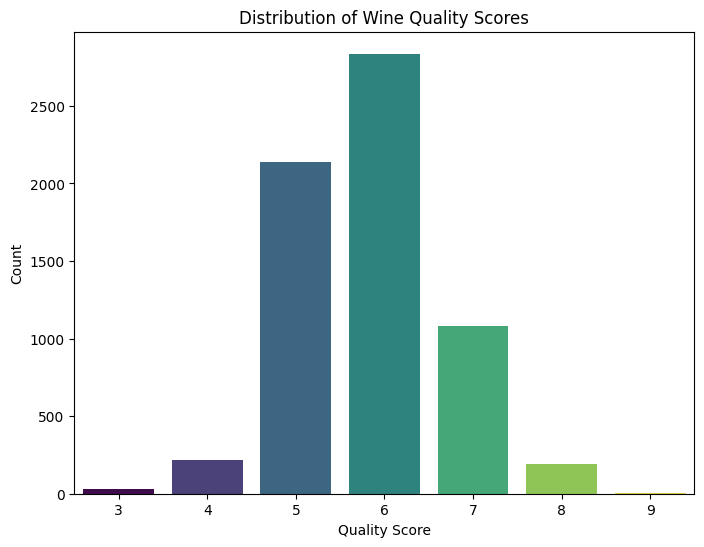

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='quality', data=df, palette='viridis', hue='quality', legend=False)
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()

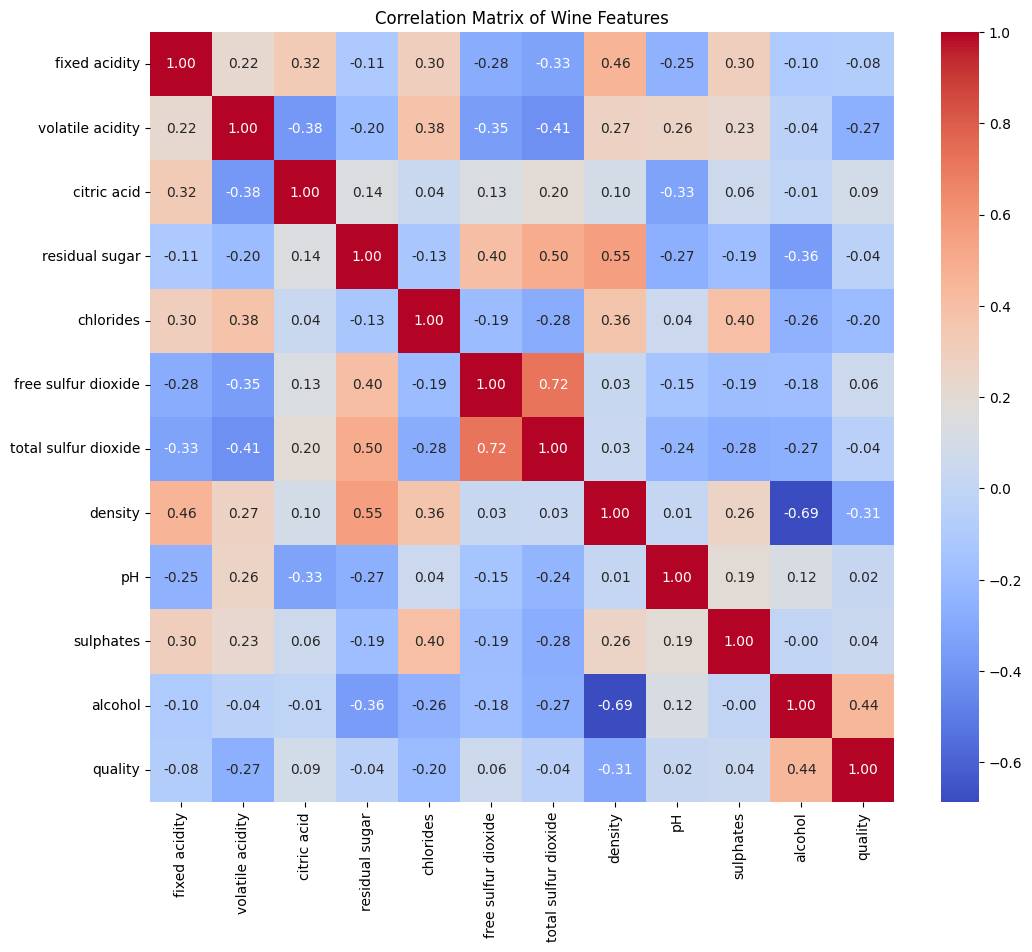

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Wine Features')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

X = df.drop('quality', axis=1)
y = df['quality']

X = pd.get_dummies(X, columns=['type'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data preparation complete. Shapes of the datasets:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

Data preparation complete. Shapes of the datasets:
X_train: (5197, 12)
X_test: (1300, 12)
y_train: (5197,)
y_test: (1300,)


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.6961538461538461

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       1.00      0.13      0.23        46
           5       0.71      0.77      0.74       420
           6       0.68      0.79      0.73       579
           7       0.72      0.51      0.60       221
           8       0.73      0.25      0.37        32

    accuracy                           0.70      1300
   macro avg       0.64      0.41      0.44      1300
weighted avg       0.71      0.70      0.68      1300



In [ ]:
import joblib
joblib.dump(model,"model.pkl")

['model.pkl']